# Football Player Evaluation Model - Analysis



## 0. Setup - Imports and Configuration

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import config
from src.analysis.game_utils import game_summary
from src.analysis.prediction_utils import normalize_predictions, print_top_predictions, visualize_top_sequences_matches, create_top_sequences
from src.data.data_loader import load_statsbomb_socceraction_data
from src.ml.models.model_factory import load_model
from src.ml.preprocessing.sequence_preprocessor import SequencePreprocessor, PreprocessingMode
from src.ml.preprocessing.xthreat import get_default_xt_model


In [2]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [3]:
data = load_statsbomb_socceraction_data("data/statsbomb/data", 55, 282)
all_matches = list(data)

# Sort matches by game_date
all_matches.sort(key=lambda x: x[0].get('game_date', ''), reverse=True)

len(all_matches)


Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loading events for match 3942752 (3/51)...
Loading events for match 3942382 (4/51)...
Loading events for match 3942349 (5/51)...
Loading events for match 3930180 (6/51)...
Loading events for match 3930171 (7/51)...
Loading events for match 3942227 (8/51)...
Loading events for match 3942226 (9/51)...
Loading events for match 3938645 (10/51)...
Loading events for match 3930184 (11/51)...
Loading events for match 3941022 (12/51)...
Loading events for match 3941021 (13/51)...
Loading events for match 3941020 (14/51)...
Loading events for match 3941019 (15/51)...
Loading events for match 3941018 (16/51)...
Loading events for match 3941017 (17/51)...
Loading events for match 3930182 (18/51)...
Loading events for match 3930179 (19/51)...
Loading events for match 3940983 (20/51)...
Loading events for match 3940878 (21/51)...
Loading events for match 3930177 (22/5

51

### 1.1 Validation Set Matches Information

In [4]:
matches_info = []

for match, events_df in all_matches:
    matches_info.append(game_summary(match))

for match in matches_info:
    print(match)


Spain 2 : 1 England (Final) [14.07.2024]
Netherlands 1 : 2 England (Semi-finals) [10.07.2024]
Spain 2 : 1 France (Semi-finals) [09.07.2024]
Netherlands 2 : 1 Turkey (Quarter-finals) [06.07.2024]
England 1 : 1 Switzerland (Quarter-finals) [06.07.2024]
Portugal 0 : 0 France (Quarter-finals) [05.07.2024]
Spain 2 : 1 Germany (Quarter-finals) [05.07.2024]
Austria 1 : 2 Turkey (Round of 16) [02.07.2024]
Romania 0 : 3 Netherlands (Round of 16) [02.07.2024]
Portugal 0 : 0 Slovenia (Round of 16) [01.07.2024]
France 1 : 0 Belgium (Round of 16) [01.07.2024]
Spain 4 : 1 Georgia (Round of 16) [30.06.2024]
England 2 : 1 Slovakia (Round of 16) [30.06.2024]
Germany 2 : 0 Denmark (Round of 16) [29.06.2024]
Switzerland 2 : 0 Italy (Round of 16) [29.06.2024]
Czech Republic 1 : 2 Turkey (Group Stage) [26.06.2024]
Georgia 2 : 0 Portugal (Group Stage) [26.06.2024]
Ukraine 0 : 0 Belgium (Group Stage) [26.06.2024]
Slovakia 1 : 1 Romania (Group Stage) [26.06.2024]
Denmark 0 : 0 Serbia (Group Stage) [25.06.2024

## 2. Load Trained Model

In [5]:
# Load the best trained model
MODEL_TYPE = 'transformer'
model = load_model(MODEL_TYPE)
print(f"Model type: {MODEL_TYPE}")


Model type: transformer


In [6]:
# Display model architecture
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 6, 46)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 6, 46)     │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 6, 46)     │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6, 128)    │      6,016 │ masking_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 6)         │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_positional_enc… │ (None, 6, 128)    │        768 │ dense_1[0][0],    │
│ (AddPositionalEnco… │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 6, 128)    │     66,048 │ add_positional_e… │
│ (MultiHeadAttentio… │                   │            │ add_positional_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 6, 128)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 6, 128)    │          0 │ add_positional_e… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 6, 128)    │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 6, 512)    │     66,048 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 6, 128)    │     65,664 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 6, 128)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 6, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 6)         │          0 │ any_1[0][0],      │
│ (LogicalOr)         │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 6, 128)    │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_1        │ (None, 6)         │          0 │ logical_or[0][0], │
│ (LogicalOr)         │                   │            │ logical_or[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights_… │ [(None, 6, 128),  │     66,182 │ layer_normalizat… │
│ (AttentionWeightsL… │ (None, 6)]        │            │ logical_or_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 6, 128)    │          0 │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,235,351 (4.71 MB)

 Trainable params: 411,783 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 823,568 (3.14 MB)

## 3. Preprocess Data for Analysis

In [7]:
# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    minimum_sequence_length=config.MINIMUM_SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

# Process validation set for analysis
X, y, p, m = preprocessor.process_matches(all_matches, mode=PreprocessingMode.VALIDATION)
print(f"Validation set preprocessed: {X.shape[0]} sequences")


→Processing match 3943043: 3312 events (mode: validation)
 → Generated 124 sequences, 124 labels for match 3943043
→Processing match 3942819: 3485 events (mode: validation)
 → Generated 97 sequences, 97 labels for match 3942819
→Processing match 3942752: 3328 events (mode: validation)
 → Generated 132 sequences, 132 labels for match 3942752
→Processing match 3942382: 3415 events (mode: validation)
 → Generated 105 sequences, 105 labels for match 3942382
→Processing match 3942227: 4882 events (mode: validation)
 → Generated 134 sequences, 134 labels for match 3942227
→Processing match 3942349: 5190 events (mode: validation)
 → Generated 158 sequences, 158 labels for match 3942349
→Processing match 3942226: 4463 events (mode: validation)
 → Generated 187 sequences, 187 labels for match 3942226
→Processing match 3941022: 3722 events (mode: validation)
 → Generated 146 sequences, 146 labels for match 3941022
→Processing match 3941021: 2996 events (mode: validation)
 → Generated 130 sequenc

In [8]:
X.shape

(6823, 6, 46)

In [9]:
p.shape

(6823,)

In [10]:
p[0:200]

array([   game_id                     original_event_id  period_id  time_seconds  team_id  player_id   start_x  start_y      end_x    end_y  type_id  result_id  bodypart_id  action_id team_name      player_name  possession type_name  duration  under_pressure  counterpress   xG  possession_team_id possession_team_name        xT       dx      dy   distance     angle  time_diff  opposite_action
       0  3943043  152820f0-6ca9-4df3-943b-a67d568ff472          1         0.340      768    99174.0  52.45625  34.0425   22.18125  35.0625        0          1            5          0   England    Kobbie Mainoo           2      Pass  2.529454           False         False  0.0                 768              England  0.010165 -30.2750   1.020  30.292178  3.107914      0.000                0
       1  3943043  9c107df3-a3c8-4ad5-bc35-00214087a105          1         2.870      768     3468.0  22.18125  35.0625   25.06875  41.1825       21          1            0          1   England  Jordan Pickford

## 4. Analysis


#### Extract match information from all matches

In [11]:
from src.analysis.prediction_utils import matches_info_df

matches_df = matches_info_df(all_matches)
matches_df.head(10)

,match_id,summary,events_count
0,3943043,Spain 2 : 1 England (Final) [14.07.2024],3312
1,3942819,Netherlands 1 : 2 England (Semi-finals) [10.07.2024],3485
2,3942752,Spain 2 : 1 France (Semi-finals) [09.07.2024],3328
3,3942382,Netherlands 2 : 1 Turkey (Quarter-finals) [06.07.2024],3415
4,3942227,England 1 : 1 Switzerland (Quarter-finals) [06.07.2024],4882
5,3942349,Portugal 0 : 0 France (Quarter-finals) [05.07.2024],5190
6,3942226,Spain 2 : 1 Germany (Quarter-finals) [05.07.2024],4463
7,3941022,Austria 1 : 2 Turkey (Round of 16) [02.07.2024],3722
8,3941021,Romania 0 : 3 Netherlands (Round of 16) [02.07.2024],2996
9,3941020,Portugal 0 : 0 Slovenia (Round of 16) [01.07.2024],4221


#### Predictions for all matches

In [12]:
predictions = model.predict(X, batch_size=32, verbose=0)

In [13]:
predicted_values, attention_weights = normalize_predictions(predictions)
print(f"Total sequences analyzed: {len(predicted_values)}")
print(f"Sum of all predicted values: {predicted_values.sum():.3f}")
print(f"Has attention weights: {attention_weights is not None}")

Total sequences analyzed: 6823
Sum of all predicted values: 397.190
Has attention weights: True


#### Get top 8 sequences by predicted value across all matches

In [14]:
number_of_top_predictions = 8
print_top_predictions(predicted_values, p, m, number_of_top_predictions, attention_weights)


Top 8 sequences with highest predicted values:

1. Match ID = 3930160, Possession ID =       game_id                     original_event_id  period_id  time_seconds  team_id  player_id    start_x  start_y      end_x    end_y  type_id  result_id  bodypart_id  action_id team_name            player_name  possession    type_name  duration  under_pressure  counterpress        xG  possession_team_id possession_team_name        xT      dx     dy  distance     angle  time_diff  opposite_action
1216  3930160  8e9f4853-4aff-4f2a-9b8d-7031c5223afe          2       569.497      772     5721.0   98.56875  40.3325   98.56875  40.3325        9          0            0       1216     Spain  Daniel Carvajal Ramos         105         Duel  0.000000            True         False  0.000000                 785              Croatia  0.257454  0.0000  0.000  0.000000  0.000000      0.485                1
1217  3930160  1b67c054-08ea-45c5-8e6e-d6e4d2b236d3          2       570.867      785    49337.0   97.8687

#### Top possessions information

In [15]:
top_possessions_df_matches = create_top_sequences(p, predicted_values, attention_weights, m, head=80)
top_possessions_df_matches.to_csv(f"models/{MODEL_TYPE}/top_possessions_all_matches_df.csv", index=False)
top_possessions_df_matches.head()

,possession_id,value,attention_weights,game_id,team_id,team_name,period,time_start,time_end,outcome
0,105,1.304733,"[0.16183005, 0.16288975, 0.16693738, 0.18921787, 0.16764066, 0.15148425]",3930160,785,Croatia,2,3269,3274,Shot
1,69,1.007855,"[0.13746956, 0.119140126, 0.21922965, 0.20426638, 0.052851636, 0.26704267]",3930170,944,Slovenia,1,2221,2224,Shot
2,93,0.817693,"[0.08095518, 0.12737347, 0.11473516, 0.22102794, 0.15441036, 0.30149782]",3938638,905,Romania,2,3384,3387,Goal
3,77,0.597151,"[0.12595488, 0.13488746, 0.107360624, 0.24702276, 0.09907692, 0.28569734]",3930178,785,Croatia,2,3247,3257,Goal
4,107,0.585379,"[0.14552414, 0.34542948, 0.11351305, 0.10730103, 0.14295882, 0.14527345]",3930184,912,Czech Republic,2,3918,3925,Goal


#### Visualize top 8 possessions from validation set on the pitch

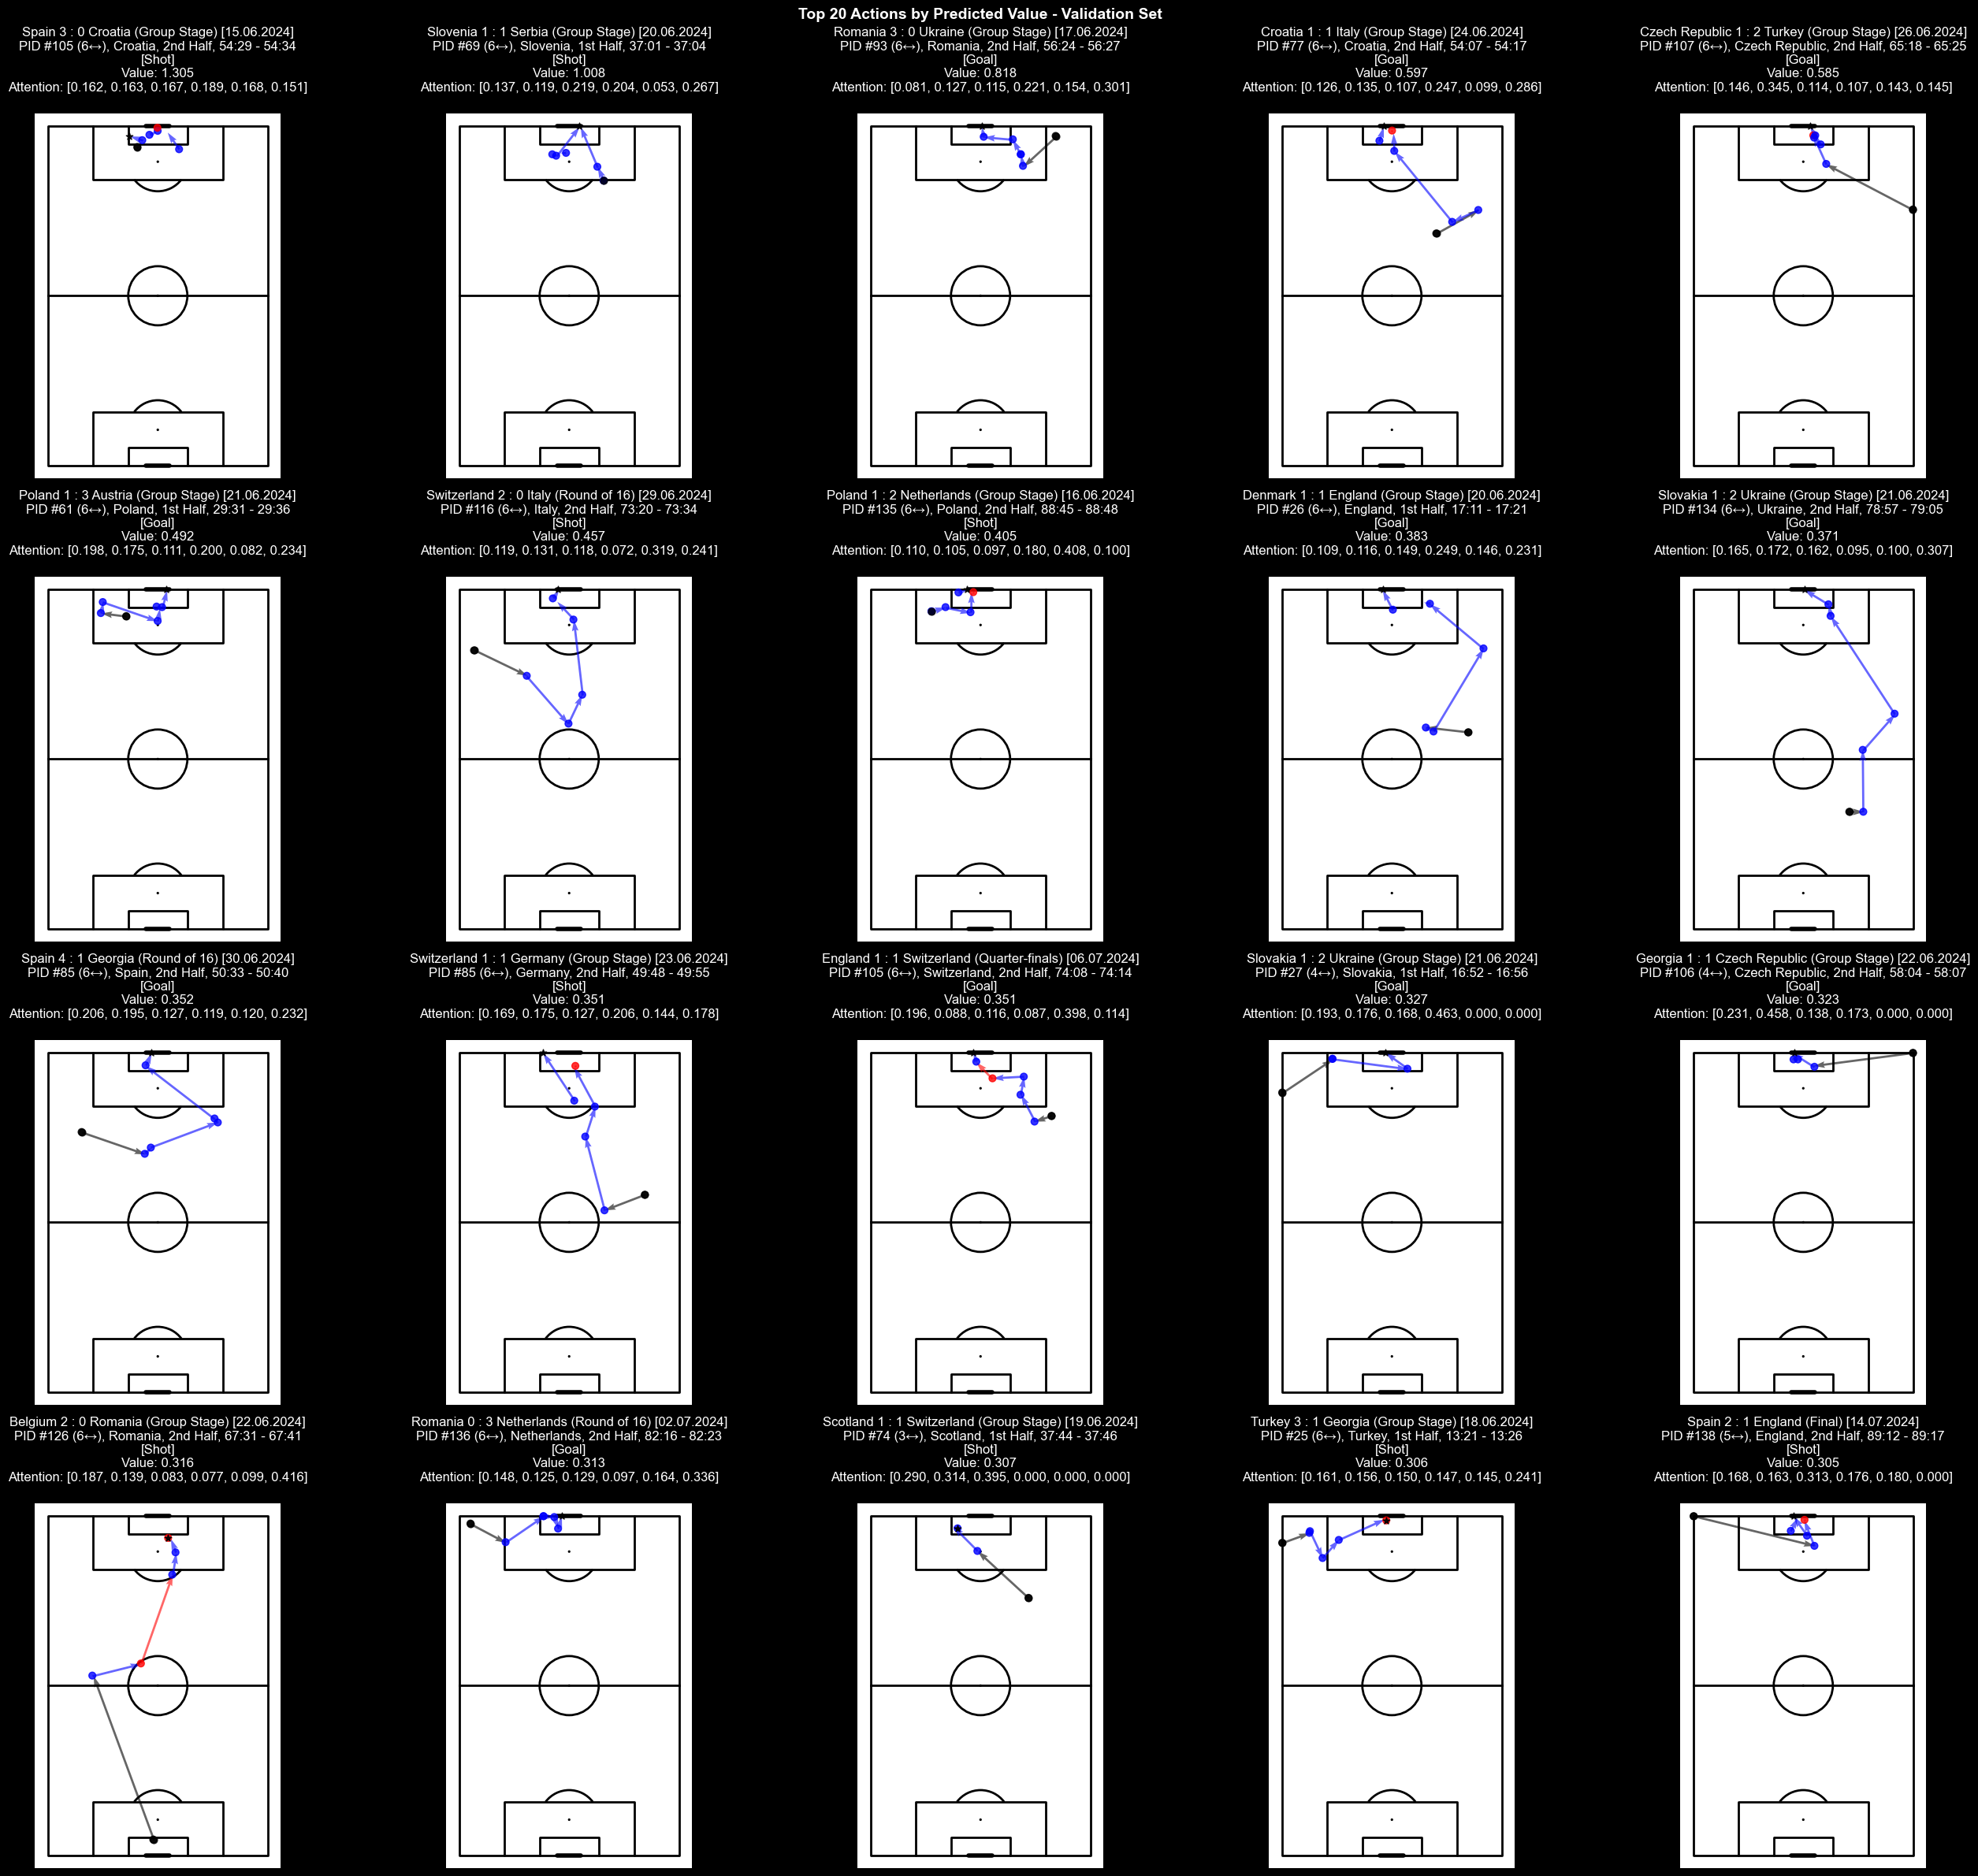

In [16]:
visualize_top_sequences_matches(p, m, predicted_values, attention_weights, all_matches, config.SEQUENCE_LENGTH, head=20)
plt.savefig(f"models/{MODEL_TYPE}/top_possessions_all_matches.png", dpi=300)
